## Runnables:

To execute chain we need the help of runnables

A Runnable is anything in LangChain that can receive an input and produce an output using a standard interface such as .invoke()

Once you understand this, LCEL (LangChain Expression Language), RunnableSequence, RunnableParallel, RunnablePassthrough, RunnableLambda, RunnableBranch, streaming, batching, and composition all become much easier.

## What exactly is a Runnable?

Think of a Runnable as a machine.

In [1]:
# INPUT
#   ↓
# ┌──────────────┐
# │   Runnable   │
# └──────────────┘
#   ↓
# OUTPUT

model.invoke("What is AI?") Here the model is runnable

prompt.invoke({"topic": "AI"}) here prompt is a runnable

parser.invoke(response) here parser is a runnable

chain.invoke(input) here chain is a runnable ,Therefore you can put a chain inside another chain.

## The universal Runnable interface

Most of the time you'll interact with Runnables through these methods:

1. .invoke()
2. .batch()
3. .stream()

and asynchronous versions:

1. .ainvoke()
2. .abatch()
3. .astream()

In [ ]:
# Method	         Meaning
# .invoke()	    Process one input
# .batch()	    Process many inputs
# .stream()	    Produce output progressively
# .ainvoke()	Async single input
# .abatch()	    Async multiple inputs
# .astream()	Async streaming

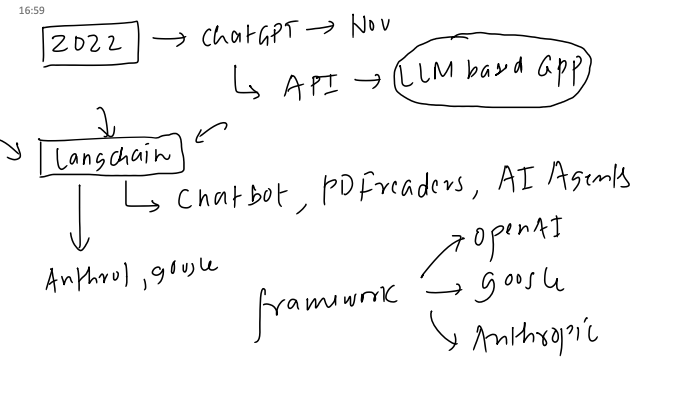

In 2022, Chatgpt was released in November and openAI released their API for general public to create your own LLM based application

Langchain team realized LLM based applications will have a lot of demand. Every company has a chatbot, pdf readers, AI agents.  They decided lets create a framework which will make it easier to build LLM based applications. They thought there are many companies which built LLMs like OpenAI,Google,Anthropic etc. 

Problem: every company's API behave differently, langchain team decided lets create a framework by which you can communicate with LLM Api of any company by doing Minimum code changes

Initially, different companies had different LLM APIs.

For example:

- OpenAI
- Anthropic
- Google
- Mistral

Each provider had its own API style. Without an abstraction layer, your code might look conceptually like:

openai_response = openai_client.generate(...) and switching providers could require significant code changes.

LangChain created abstractions so that you could work with different models through a relatively consistent interface.


Problem 2: There are many challenges apart from Interacting with LLM for building LLM based application.real-world applications are much more complicated.

## Example: PDF Question Answering application

Suppose you want to build: Chat with your PDF

A user uploads a 200-page PDF and asks: "What is the company's revenue in 2025?"

Your application might need to do this:

In [ ]:
# PDF
#  ↓
# Load PDF
#  ↓
# Split into chunks
#  ↓
# Create embeddings
#  ↓
# Store embeddings
#  ↓
# Vector Database
#  ↓
# Retriever
#  ↓
# Semantic Search
#  ↓
# Relevant chunks
#  ↓
# Prompt
#  ↓
# LLM
#  ↓
# Answer
#  ↓
# Output Parser
#  ↓
# User



# Notice The LLM is only one component. You also have:

# Document Loader
# Text Splitter
# Embedding Model
# Vector Store
# Retriever
# Prompt
# LLM
# Output Parser

# This is the first major idea.

Langchain team realized we were only focusing on the LLM part not on the other components. So they created components of important parts.



If I want to develop a LLM based app, I want to connect all these components together 

In [ ]:
from langchain_openai import OpenAI
from langchain_core.prompts import PromptTemplate

llm=OpenAI(model='gpt-3.5-turbo',temperature=0.3)

prompt=PromptTemplate(
    template="suggest a catchy blog title about {topic}",
    input_variables=['topic']
)

topic=input("Enter a topic")

formatted_prompt=prompt.format(topic=topic)

blog_title=llm.predict(formatted_prompt)
print("generated blog title:",blog_title)

## PDF Reader Application

In [10]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_community.vectorstores import Chroma
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
load_dotenv()


True

In [12]:
## Load the document

loader=TextLoader('pokemon.txt') ## Ensure pokemon.txt exists
documents=loader.load()

## Split the documents into chunks

splitter=RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
docs=splitter.split_documents(documents)

## Create an embedding model
embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

## Convert the docs into embeddings
vectorstore=Chroma.from_documents(embedding=embedding_model,documents=docs)

## create a retreiver
retriever= vectorstore.as_retriever()

## manually Retrieve Relevant documents
query="How many types are there in Pokemon? "
retrieved_docs=retriever.invoke(query)

## combined the retrieved text 

retrieved_text="\n".join([doc.page_content for doc in retrieved_docs])

## Initalize the LLM
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')


## Manually pass retrieved text to LLM

prompt=f"Based on the following text, answer the question:{query}\n\n{retrieved_text}"
answer=model.invoke(prompt)

## print the answer
print("Answer:",answer)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Answer: content=[{'type': 'text', 'text': 'Based on the provided text, there are **18** distinct elemental types in Pokémon.', 'extras': {'signature': 'EtoFCtcFARFNMg/iQAIAbHoWeE2iFCcyUtebf8pe8hE+Y096zgNKT9H6UPqA/Y4WVhL1qdMb2dI4LelYF3GiLPjKcS+NG7oFMKaf3IhFX/59b7Ubm0pD5T+xyuN3WwmvKb26nYx/kBcdZjVdEYstqWkX6NgXbn/bV33du9G9X/fK9JtvhE8G+EqQY7SBXgUY57UVUXeqK2PAtAW/UAevwSM5dBiGGiZWL/zR0ZsCSd74U6bEpO/7WNuqWk2KXs1SlL0pFa/RTu1Qwt5/waGqXbRTNmlxrf+En3YrnkWNSN2mKtmkUUzR3M6GuxyCVPG0LWwJtzWzm38eX25xsmMV6xFxFeanUBMzwls9QzExEbc0yVkWcXtd+UwEPNKkpp37wiam2AaUnY+SMRdnyHm7jFgFYMV0Adp2kyZ5t+SqwR4dGHbu8dcsNPk22AuMsJmk4Gp447/dJaSoWjpnjL++K6PY50AqxMs4+ot+6K8/XwwXztauMlcOJ4+IdqTjLi0tg7yQMSK8PAR9wIlgZE7tTFakjVD3HYQZsR0H5zIRlqwb+clpM90BXOXQ18bS0HykdBm0v4xtFeIUIlf7X0vFPln0uf/K5Y6Rjmz+OSILVfBw3AKnjVITe/WqqgB2pJ8DB4YUjSJbiuBayrbEger+28DLSFqXdsUx3hO6B3g+FGjxcpccvOmGtUoBlJ8hQfr8MewNnawGz6IqTK1D+rrQZwOFi0AIWaAbfVdKltLC3nza18AvEMCmyQU1kOtf1FeuXdImkKghB0RC5PnVXNvEVS4oPqkfJH1RXlGaV792O+6nSW+D04LoUheGG6oJbIXmG2AbLl79KtVpRHLH

In [13]:
answer.content

[{'type': 'text',
  'text': 'Based on the provided text, there are **18** distinct elemental types in Pokémon.',
  'extras': {'signature': 'EtoFCtcFARFNMg/iQAIAbHoWeE2iFCcyUtebf8pe8hE+Y096zgNKT9H6UPqA/Y4WVhL1qdMb2dI4LelYF3GiLPjKcS+NG7oFMKaf3IhFX/59b7Ubm0pD5T+xyuN3WwmvKb26nYx/kBcdZjVdEYstqWkX6NgXbn/bV33du9G9X/fK9JtvhE8G+EqQY7SBXgUY57UVUXeqK2PAtAW/UAevwSM5dBiGGiZWL/zR0ZsCSd74U6bEpO/7WNuqWk2KXs1SlL0pFa/RTu1Qwt5/waGqXbRTNmlxrf+En3YrnkWNSN2mKtmkUUzR3M6GuxyCVPG0LWwJtzWzm38eX25xsmMV6xFxFeanUBMzwls9QzExEbc0yVkWcXtd+UwEPNKkpp37wiam2AaUnY+SMRdnyHm7jFgFYMV0Adp2kyZ5t+SqwR4dGHbu8dcsNPk22AuMsJmk4Gp447/dJaSoWjpnjL++K6PY50AqxMs4+ot+6K8/XwwXztauMlcOJ4+IdqTjLi0tg7yQMSK8PAR9wIlgZE7tTFakjVD3HYQZsR0H5zIRlqwb+clpM90BXOXQ18bS0HykdBm0v4xtFeIUIlf7X0vFPln0uf/K5Y6Rjmz+OSILVfBw3AKnjVITe/WqqgB2pJ8DB4YUjSJbiuBayrbEger+28DLSFqXdsUx3hO6B3g+FGjxcpccvOmGtUoBlJ8hQfr8MewNnawGz6IqTK1D+rrQZwOFi0AIWaAbfVdKltLC3nza18AvEMCmyQU1kOtf1FeuXdImkKghB0RC5PnVXNvEVS4oPqkfJH1RXlGaV792O+6nSW+D04LoUheGG6oJbIXmG2AbLl79KtVpRHLHmPdhlhGoFR6Z

AI Engineers plug-in these components to build LLM based applications

Now, Langchain has a revolutionary moment:

Creating a Prompt and sending it to LLM was done manually by AI Engineers but what if I can automate this task ? What if we create builtin function in which llm,prompt_template are its arguments and after executing it, it will automatically generate prompt from prompt_template and send it to LLM " fn(llm,prompt_template)" . Langchain team calls it a chains To connect two or more components. Simple chain is LLM chain 

In [1]:
## I want to create a chain where as an input I have to just give - (LLM,Retriever) we just call it , automatically everything happens

In [3]:

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_community.vectorstores import Chroma
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_classic.chains import RetrievalQA
load_dotenv()

True

In [6]:
## Load the document

loader=TextLoader('pokemon.txt')
documents=loader.load()
splitter=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
docs=splitter.split_documents(documents)
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vectorstore=Chroma.from_documents(embedding=embedding_model,documents=docs)
retriever=vectorstore.as_retriever()

## Create RetrieverQA Chain
chain=RetrievalQA.from_chain_type(llm=model,retriever=retriever)


query="Who is Ash Ketchum and name his pokemons ?"
answer=chain.run(query)
print("Answer:",answer)


### You do not need to design the prompt by yourself, you do not need to join the retrieved documents

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Answer: Based on the provided text, **Ash Ketchum** is the main protagonist of *Pokémon the Series* and the first overall protagonist of the Pokémon animated series. He is a 10-year-old boy from Pallet Town in the Kanto region, and the son of Delia Ketchum. 

As for his Pokémon, the provided text does not list the specific Pokémon he owns (other than mentioning the manga title *The Electric Tale of Pikachu*), so I don't know the answer to that part based on the given information.


## Types of chain 

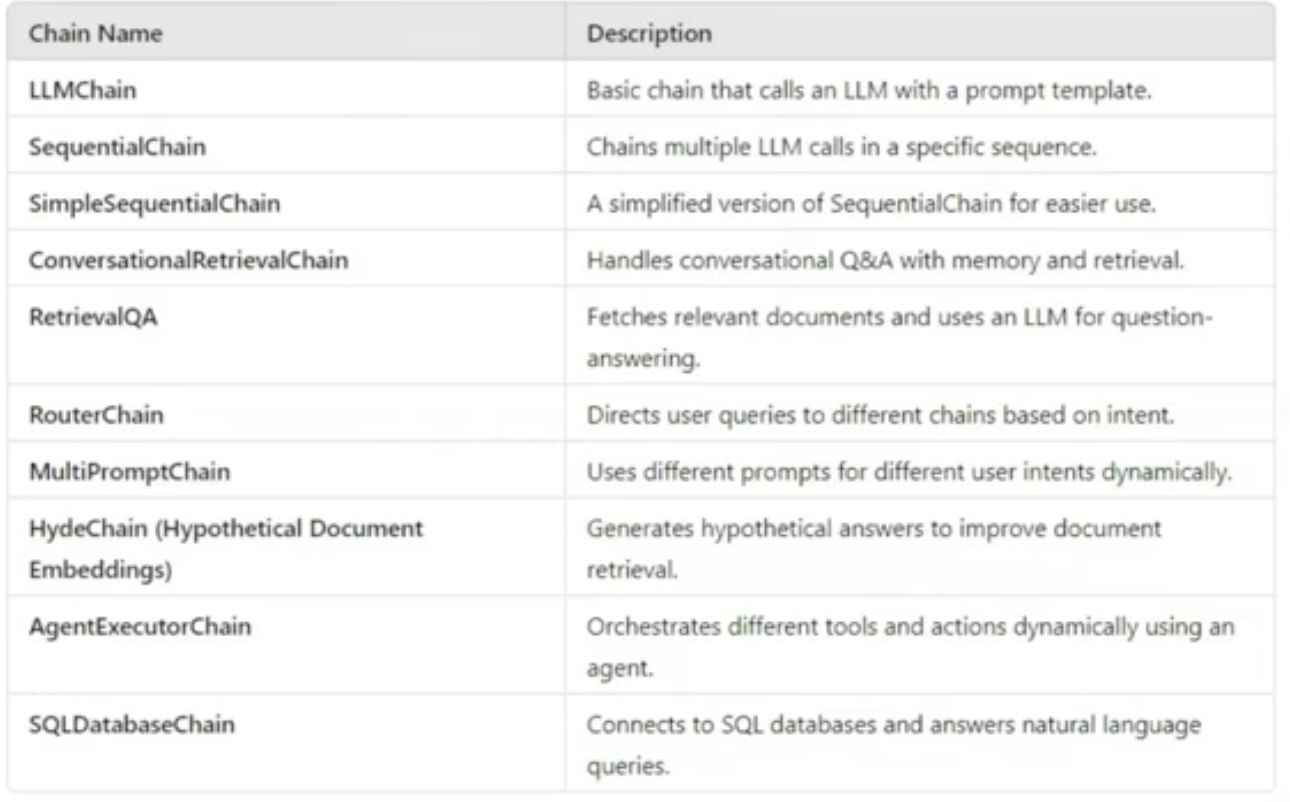

They can form chains by joining different different components

## Problem:

1. Too many chains: 

- Codebase becomes large . It is problematic to maintain a big codebase
- New AI Engineer gets confused in learning

Earlier, LangChain had many different components:

- LLM
- Prompt Template
- Retriever
- Output Parser etc.

## Why they need to create soo many chains ?

The goal was that AI engineers should be able to combine these components like LEGO blocks and create different AI workflows. However, there was a problem. The components were not standardized. Different components used different methods:

LLM             → predict()

Prompt Template → format()

Retriever       → get_relevant_documents()

Parser          → parse()


Because every component had a different interface, they could not be seamlessly connected. Therefore, LangChain had to write a separate custom Chain for different combinations/use cases.

Example: Prompt + LLM -> LLMChain
         
         Retriever + Prompt + LLM -> RetrievalQAChain

This eventually resulted in too many Chains, a larger codebase, and a steeper learning curve for developers.

For every new workflow, developers needed new custom logic. prompt.format(),  llm.predict().. All components should follow the same standard.

## Solution: Runnables

LangChain introduced Runnables to standardize all components.

The simplest definition is: A Runnable is a unit of work that accepts an input, processes it, and returns an output.

The important part is that all Runnables follow a common interface.

For example, instead of:

llm.predict(), prompt.format(), parser.parse()

the standardized approach becomes:

llm.invoke(), prompt.invoke(), parser.invoke()

***Now every component has the same way of being called: invoke(input)***

## Characteristics of Runnable: 

 ***Characteristic 1: A Runnable performs one task***

Conceptually: Input -> Runnable -> Output

Example : Topic:India -> Prompt Runnable -> "Write a poem about India"

or Prompt -> LLM Runnable -> Generated Response

***Characteristic 2: Every Runnable follows a common interface***

Every Runnable has common methods such as:

- invoke()
- batch()
- stream()

batch() -> used to process multiple inputs:


runnable.batch([input1,input2,input3,...])




stream() -> Returns output gradually

For example, an LLM can stream:

Hello

Hello, how

Hello, how are

Hello, how are you?

The most important idea here is: Every component behaves through a standardized interface.

## Because interfaces are standardized, Runnables can be connected


## characeristics 3: Runnables can be connected
Imagine three Runnables:

R1 → R2 → R3

The important mechanism is:

Output of R1 -> Input of R2 -> Output of R2 -> Input of R3

Mathematically, you can imagine:

R1(input) → output1

R2(output1) → output2

R3(output2) → final_output

Because every component has:

invoke()

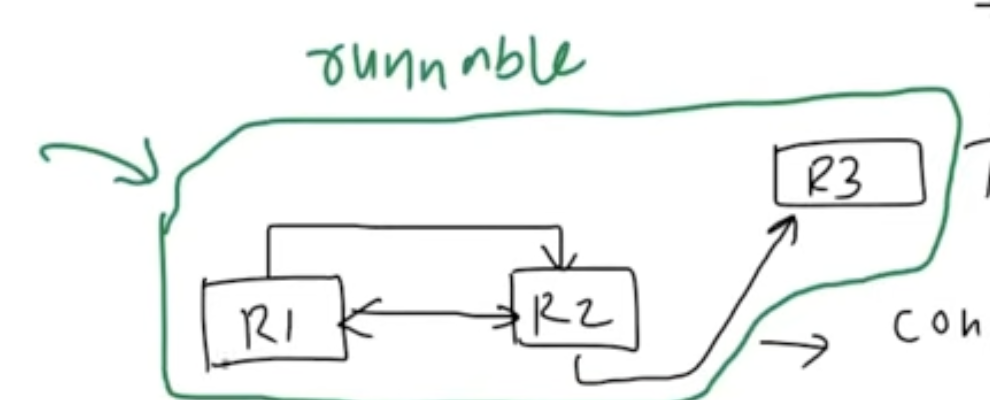

This complete workflow is itself a runnable


## Characteristics 4: A Chain is also a Runnable



In [ ]:
# Runnable
#    +
# Runnable
#    +
# Runnable
#    ↓
# Chain



# Chain
#    +
# Chain
#    ↓
# Bigger Chain

Runnable can be compared to LEGO Blocks

the LEGO analogy is perfect

Each LEGO block:

- Has its own purpose.
- Has a standardized connection mechanism.
- Can connect with other blocks.
- A group of connected LEGO blocks can become a bigger structure.

## How runnables ?

In [13]:
# Dummy LLM
# Something conceptually like:
import random
class FakeLLM:

    def __init__(self):
        print("LLM Created")

    def predict(self,prompt):
        response_list=['Delhi is the capital of India','IPL is a cricket league','AI stands for Artifical Intelligence']
        return {'response':random.choice(response_list)}
llm=FakeLLM()

llm.predict('What is the capital of India')

LLM Created


{'response': 'Delhi is the capital of India'}

In [14]:
# And a Prompt Template:

class FakePromptTemplate:

    def __init__(self,template,input_variables):
        self.template=template
        self.input_variables=input_variables

    def format(self, input_dict):
        return self.template.format(**input_dict)

# Now to build an application, you manually need to write:

template=FakePromptTemplate(
    template="Write a poem about {topic}",
    input_variables=['topic']
)

template.format({'topic':'India'})
# This represents the old problem.

# You have to manually connect the components.

'Write a poem about India'

In [15]:
template=FakePromptTemplate(
    template='Write a {length} poem about {topic}',
    input_variables=['length','topic']
)
template.format({'length':'short','topic':'Pinnocio'})

'Write a short poem about Pinnocio'

In [16]:
prompt=template.format({'length':'short','topic':'Pinnocio'})
llm=FakeLLM()

llm.predict(prompt)

LLM Created


{'response': 'AI stands for Artifical Intelligence'}

## FakeLLM chain

In [17]:
class FakeLLMChain:
    def __init__(self,llm,prompt):
        self.llm=llm
        self.prompt=prompt


    def run(self,input_dict):
       final_prompt= self.prompt.format(input_dict)
       result = llm.predict(final_prompt)

       return result['response']


In [18]:
template=FakePromptTemplate(
    template='Write a {length} poem about {topic}',
    input_variables=['length','topic'])


llm=FakeLLM()
chain= FakeLLMChain(llm,template)
chain.run({'length':'short','topic':'cricket'})

LLM Created


'Delhi is the capital of India'

You would have to create another specialized Chain.

Then another use case requires another Chain.

Then another workflow requires another Chain.

Eventually you get:

1. LLMChain
2. RetrievalQAChain
3. ConversationChain
4. SequentialChain
5. StuffDocumentsChain
...

This was the fundamental scalability problem.

The transcript demonstrates that a fixed Chain class is not flexible enough to represent arbitrary workflows.

## How runnable fixed this issue ?

In [21]:

## I will create an abstract class runnable and other component classes will inherit from that Runnable class and will become runnable


In [20]:
from abc import ABC,abstractmethod


class Runnable(ABC):
    @abstractmethod
    def invoke(input_data):
        pass


In [22]:
class FakeLLM(Runnable):
    def __init__(self):
        print("LLM Created")

    def predict(self,prompt):
        response_list=['Delhi is the capital of India','IPL is a cricket league','AI stands for Artifical Intelligence']
        return {'response':random.choice(response_list)}


class FakePromptTemplate(Runnable):

    def __init__(self,template,input_variables):
        self.template=template
        self.input_variables=input_variables

    def format(self, input_dict):
        return self.template.format(**input_dict)


llm=FakeLLM()

TypeError: Can't instantiate abstract class FakeLLM without an implementation for abstract method 'invoke'

In [ ]:
## I didn't implement invoke method 

In [30]:
class FakeLLM(Runnable):
    def __init__(self):
        print("LLM Created")

    def predict(self,prompt):
        response_list=['Delhi is the capital of India','IPL is a cricket league','AI stands for Artifical Intelligence']
        return {'response':random.choice(response_list)}


    def invoke(self,prompt):
            response_list=['Delhi is the capital of India','IPL is a cricket league','AI stands for Artifical Intelligence']
            return {'response':random.choice(response_list)}



class FakePromptTemplate(Runnable):

    def __init__(self,template,input_variables):
        self.template=template
        self.input_variables=input_variables

    def invoke(self,input_dict):
         return self.template.format(**input_dict)

    def format(self, input_dict):
        return self.template.format(**input_dict)


## Standardize both the components




class RunnableConnector(Runnable):
     
     def __init__(self, runnable_list):
          self.runnable_list=runnable_list


     def invoke(self,input_data):

          for runnable in self.runnable_list:
               input_data=runnable.invoke(input_data)
          return input_data


template=FakePromptTemplate(
    template='Write a {length} poem about {topic}',
    input_variables=['length','topic'])

llm=FakeLLM()

LLM Created


In [32]:
chain=RunnableConnector([template,llm])

chain.invoke({'length':'long','topic':'India'})

{'response': 'IPL is a cricket league'}

In [34]:
class FakeStrOutputParser(Runnable):
    def __init__(self):
        pass

    def invoke(self,input_data):
        return input_data['response']


parser=FakeStrOutputParser()

In [35]:
chain=RunnableConnector([template,llm,parser])

chain.invoke({'length':'long','topic':'India'})

'Delhi is the capital of India'

In [ ]:
### Now you do not need to create custom chains 

## chain 1:input -> llm -> joke           chain 2:joke -> llm -> explanation

## we will merge both chains to create a bigger chain chain 1 and chain 2 =chain 3

In [43]:
template1=FakePromptTemplate(
    template='Write a joke about {topic}',
    input_variables=['topic']
)

template2=FakePromptTemplate(
    template='Write an explanation about following joke {response}',
    input_variables=['response']
)


llm=FakeLLM()
parser=FakeStrOutputParser()
chain1=RunnableConnector([template1,llm])
chain2=RunnableConnector([template2,llm,parser])
final_chain=RunnableConnector([chain1,chain2])

LLM Created


In [44]:
final_chain.invoke({'topic':'cricket'})

'AI stands for Artifical Intelligence'

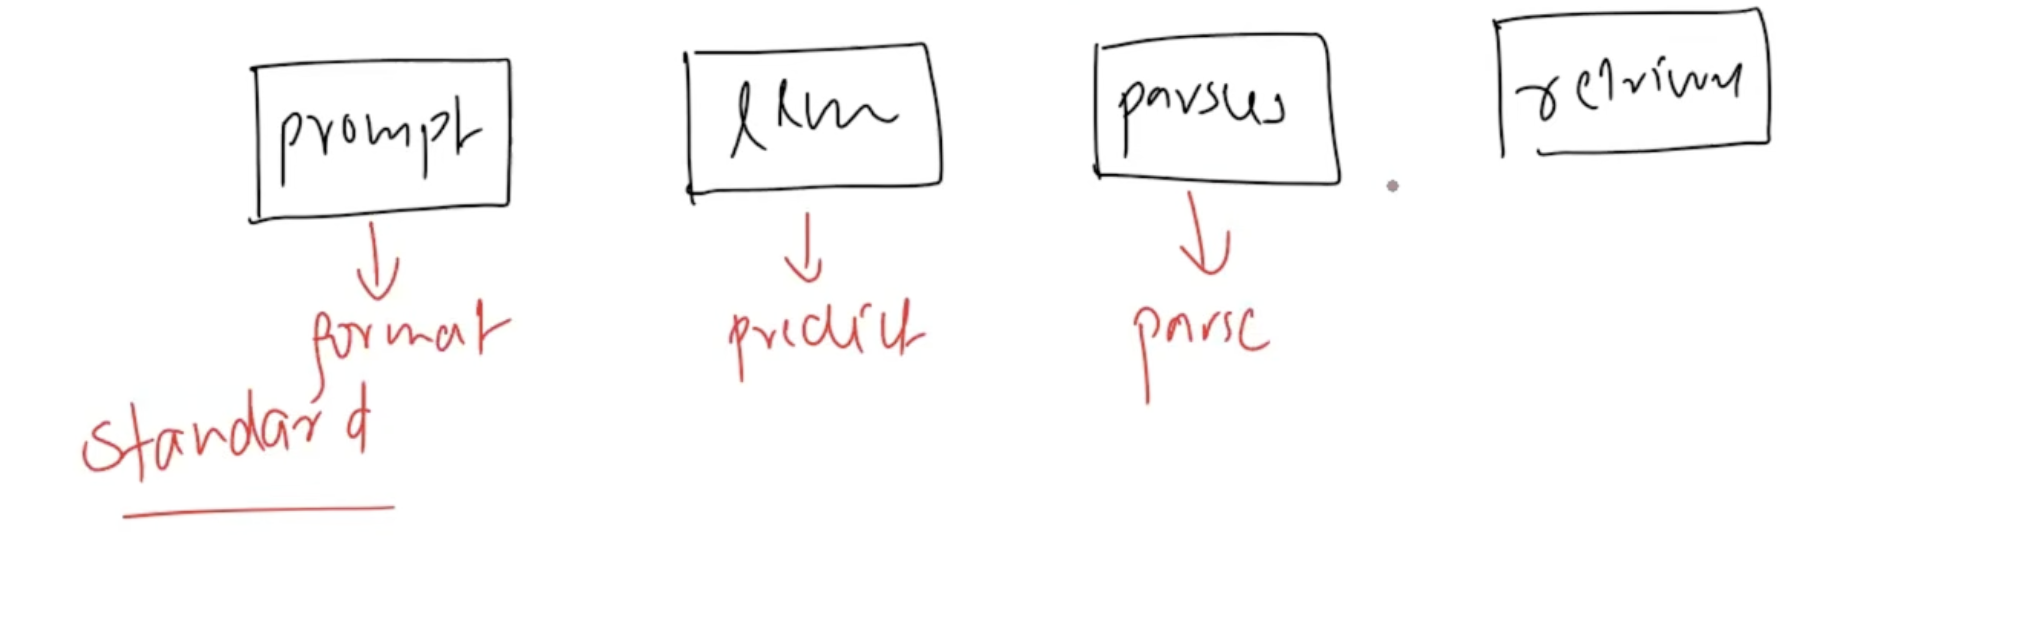

Connection was difficult as different functions to call


They standardize it and create a common function called invoke

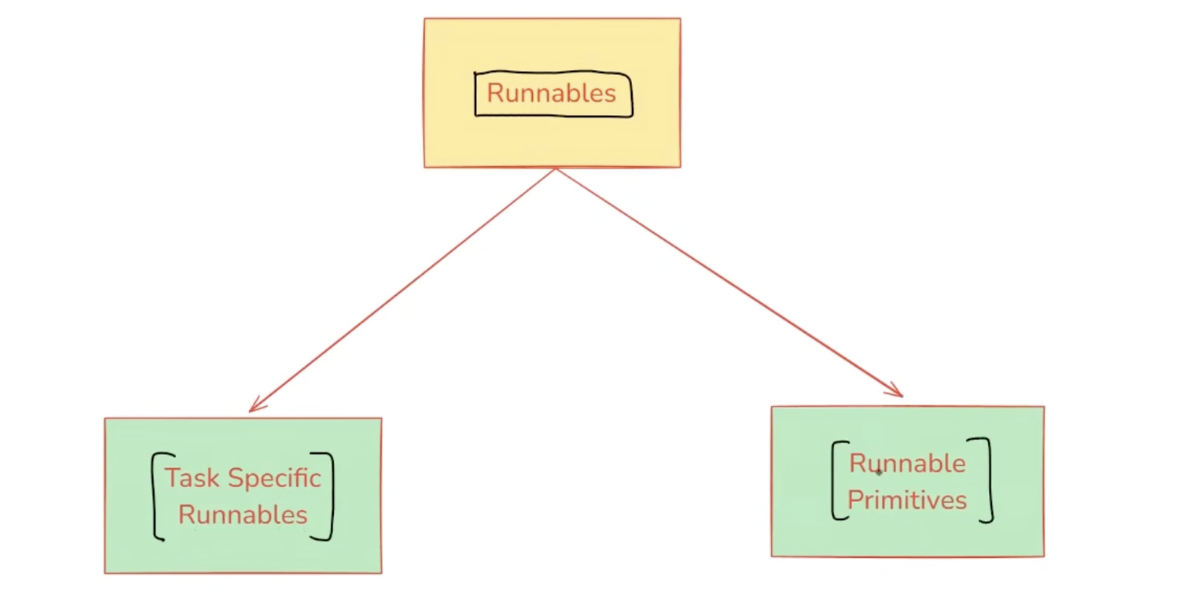

Task-Specific Runnables do the actual work.

Runnable Primitives decide how different pieces of work are connected and executed.

## Task Specific Runnables

Definition: These are core LangChain Components that have been converted into Runnables so they can be used in pipelines.These are the actual LangChain components that have their own specific purpose.

Purpose : Performs task specific operations like LLM Calling, prompting, retrieval etc

- Prompt Templates
- LLMs / Chat Models
- Retrievers
- Output Parsers

Each component performs a particular task.


## Why are these called Task-Specific Runnables?

Because each one has a specific task or responsibility.

Prompt Template → Prompt creation

LLM             → Text generation

Retriever       → Document retrieval

Parser          → Output processing

Earlier, these were simply LangChain components. Then LangChain standardized them so that they could behave as Runnables and be connected in pipelines.

So A Task-Specific Runnable is a LangChain component with its own specific purpose that also follows the Runnable interface.

## Runnable Primitives

Runnable Primitives generally do not exist primarily to perform a domain-specific task like generating text or retrieving documents.

Instead, their purpose is to:***Control, organize, and orchestrate how Task-Specific Runnables interact with each other.***

Think of them as the workflow-building tools. These are fundamental building blocks for structuring execution logic in AI workflows 


Purpose: They help orchestrate execution by defining how runnables interact (sequentally, parallely, conditionally etc)

Examples:

- RunnableSequence -> Runs steps in order (| operator)
- RunnableParallel -> Runs multiple steps simultaneously
- RunnableMap   -> Maps the same input across multiple functions.
- RunnableBranch -> Implements conditional execution (if-else logic)
- RunnableLambda -> Wraps custom python functions into Runnables
- RunnablePassthrough -> Just forwards input as output (acts as a placeholder)

In [ ]:
# The easiest analogy

# Imagine you are building a factory.

# Task-Specific Runnables = Workers/Machines
# Machine 1 → Creates prompt
# Machine 2 → Calls LLM
# Machine 3 → Parses output
# Machine 4 → Retrieves documents

# Each machine does actual work.

# Runnable Primitives = Factory workflow manager

# They decide:

# Which machine runs first?
# Which machines run together?
# Which path should be selected?
# How should the output move?

# So:

# Task-Specific Runnables
#         +
# Runnable Primitives
#         ↓
# Complete AI Workflow

## Runnable Sequence



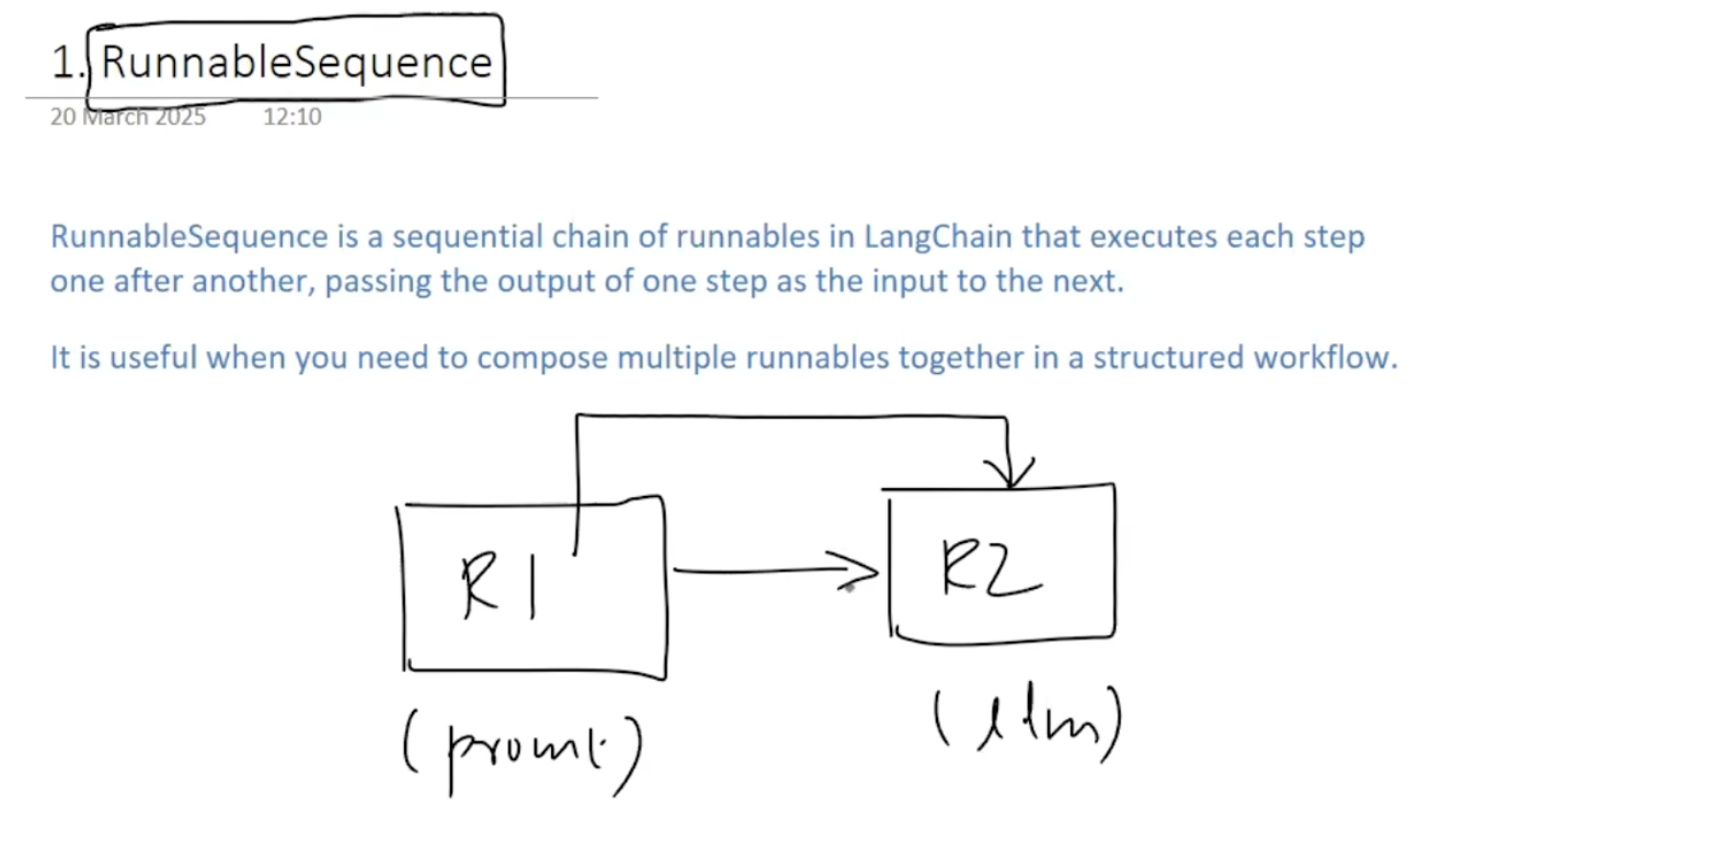

prompt -> joke -> explanation

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_classic.schema.runnable import RunnableSequence

load_dotenv()

True

In [46]:
## Runnable 1
prompt = PromptTemplate(
    template="Write a joke about {topic}",
    input_variables=['topic']
)
## Runnable 2
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

## Runnable 3
parser=StrOutputParser()

chain = RunnableSequence(prompt,model,parser)

chain.invoke({'topic':'Relationship'})


'A man and his wife are sitting in a nice restaurant celebrating their anniversary. \n\nThe husband notices a man sitting alone at the bar, knocking back shot after shot.\n\nHe turns to his wife and says, "Do you see that guy over there? He’s been drinking nonstop for the last two hours."\n\nThe wife looks over, sighs, and says, "Oh, that’s my ex-husband. He started drinking the day we got divorced ten years ago, and I hear he hasn\'t stopped since."\n\nThe husband takes a slow sip of his drink, shakes his head, and says: \n\n"My god... I had no idea anyone could celebrate for that long!"'

In [47]:
## Runnable 4

prompt2=PromptTemplate(
template="Explain the following joke -{text}",
input_variables=['text']
)

chain=RunnableSequence(prompt,model,parser,prompt2,model,parser)

print(chain.invoke({'topic':'Relationship'}))

This joke relies on a **subversion of expectations** and a play on a classic romantic cliché. Here is a breakdown of why it’s funny:

1. **The Romantic Setup:** The joke begins in a very cliché, romantic setting—a fancy restaurant on an anniversary. When the man looks into her eyes and says, *"I can't imagine my life without you,"* both the girlfriend and the audience naturally assume he is declaring his deep love for **her**.

2. **The Classic Trope:** The girlfriend responds with a common idiom: *"Is that you talking, or the wine?"* Normally, this phrase means, *"Are you actually being sincere, or are you just saying something overly emotional because the alcohol has lowered your inhibitions?"*

3. **The Punchline (The Twist):** Instead of reassuring her that he loves her, the man replies, *"It’s me... talking to the wine."* 

The humor comes from the sudden shift in context. He wasn't expressing romantic devotion to his girlfriend at all—he was professing his love for alcohol. It hi

## RunnableParallel

RunnableParallel is a runnable primitive that allows multiple runnables to execute in parallel. Each runnable receives the same input and processes it independently, producing a dictionary of outputs

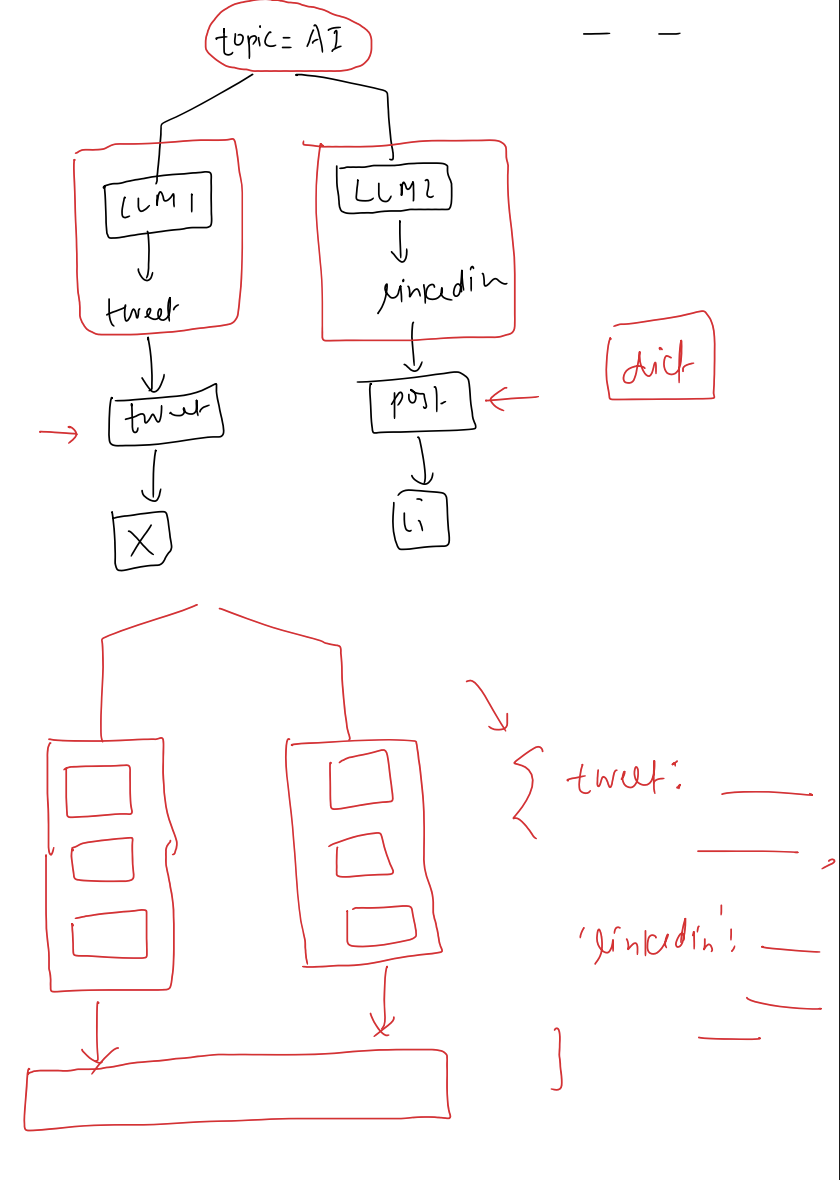

In [2]:
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_classic.schema.runnable import RunnableParallel,RunnableSequence

load_dotenv()

True

In [3]:
## Runnable 1
prompt1 = PromptTemplate(
    template="Generate a tweet about the topic: {topic}",
    input_variables=['topic']
)
## Runnable 2
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

## Runnable 3
parser=StrOutputParser()

## Runnable 4
prompt2 = PromptTemplate(
    template="Generate a linkedin post about the topic: {topic}",
    input_variables=['topic']
)


parallel_chain=RunnableParallel({
    'tweet':RunnableSequence(prompt1,model,parser),

    'linkedin':RunnableSequence(prompt2,model,parser)
}
)


result=parallel_chain.invoke({'topic':'Agentic AI'})
print(result)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'tweet': "The evolution of AI in a nutshell:\n\n2023: Ask a question, get an answer 💬\n2025: Give a goal, get it executed 🤖⚡️\n\n**Agentic AI** isn't just generating text—it’s planning, using tools, and completing complex workflows autonomously. We’re moving from chatbots to digital teammates. 🚀 #AgenticAI #AI #FutureOfWork", 'linkedin': 'Here is a high-engaging, professional LinkedIn post tailored for a business and tech audience:\n\n***\n\nStop thinking of AI as a chatbot. \nStart thinking of AI as a digital coworker. \n\nWelcome to the era of **Agentic AI**. 🤖🚀\n\nFor the last two years, we’ve been in the "Generative" phase: You give AI a prompt, and it gives you text, code, or an image. It’s passive.\n\n**Agentic AI changes the game completely.** \n\nInstead of waiting for instructions, AI Agents operate autonomously to achieve a specific goal. You don\'t just ask them questions—you delegate complex workflows to them.\n\nHere is why Agentic AI is the biggest shift in tech right no

In [4]:
print(result['tweet'])

The evolution of AI in a nutshell:

2023: Ask a question, get an answer 💬
2025: Give a goal, get it executed 🤖⚡️

**Agentic AI** isn't just generating text—it’s planning, using tools, and completing complex workflows autonomously. We’re moving from chatbots to digital teammates. 🚀 #AgenticAI #AI #FutureOfWork


In [5]:
print(result['linkedin'])

Here is a high-engaging, professional LinkedIn post tailored for a business and tech audience:

***

Stop thinking of AI as a chatbot. 
Start thinking of AI as a digital coworker. 

Welcome to the era of **Agentic AI**. 🤖🚀

For the last two years, we’ve been in the "Generative" phase: You give AI a prompt, and it gives you text, code, or an image. It’s passive.

**Agentic AI changes the game completely.** 

Instead of waiting for instructions, AI Agents operate autonomously to achieve a specific goal. You don't just ask them questions—you delegate complex workflows to them.

Here is why Agentic AI is the biggest shift in tech right now:

🔹 **From Answers to Actions:** An agent doesn't just write a sales email; it researches the prospect, drafts the message, checks your calendar for availability, sends the invite, and updates your CRM.

🔹 **Tool Integration:** Agents can interact with APIs, databases, software applications, and web browsers just like a human would.

🔹 **Reasoning & Adap

## RunnablePassThrough

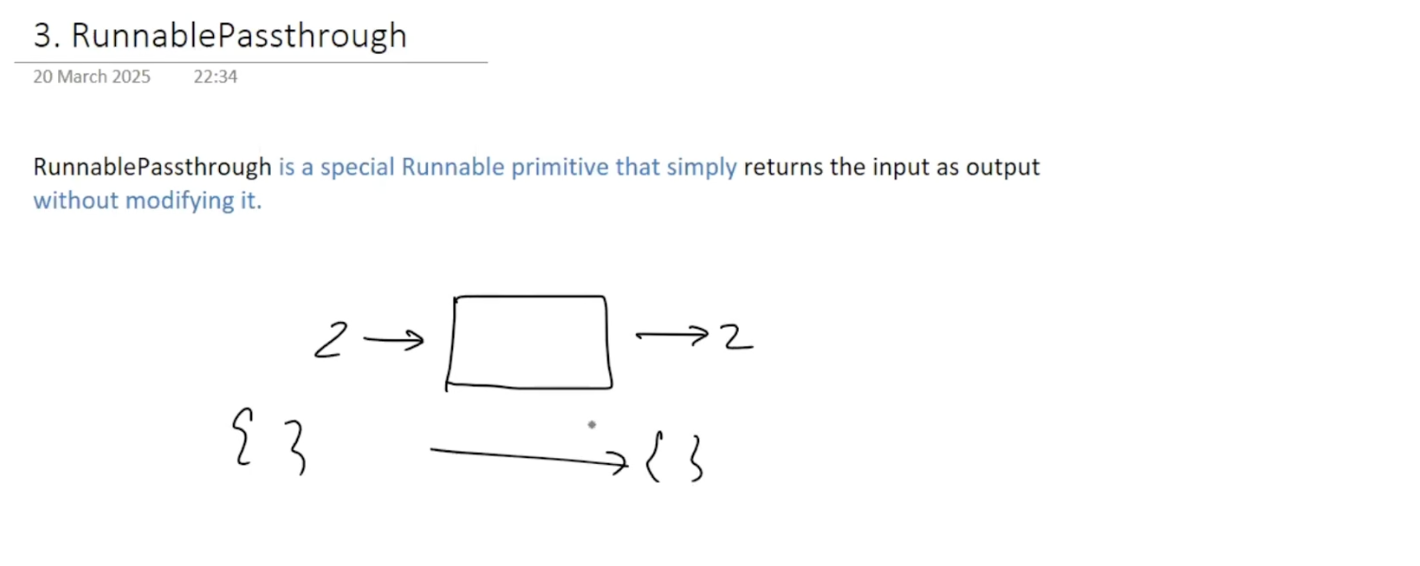

topic -> llm -> joke -> llm -> explanation

Problem: Final output has only explanation not with joke. What if I want to print both joke and explanation

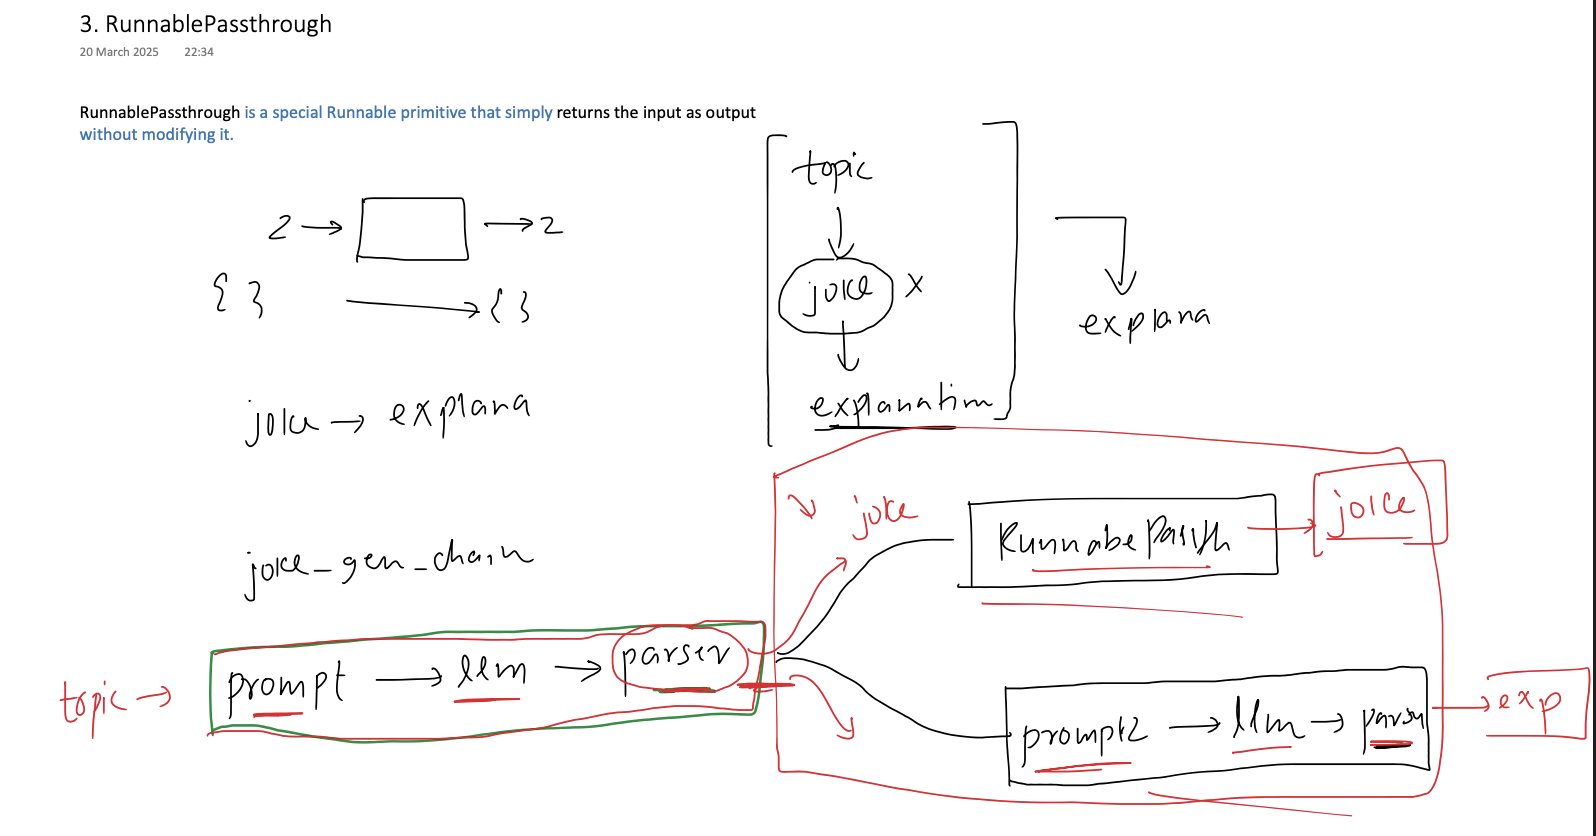

In [6]:
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_classic.schema.runnable import RunnableParallel,RunnableSequence,RunnablePassthrough

load_dotenv()

True

In [7]:
passthrough=RunnablePassthrough()


print(passthrough.invoke(2))

2


In [8]:
print(passthrough.invoke({'name':'Anya'}))

{'name': 'Anya'}


In [10]:
## Runnable 1
prompt1= PromptTemplate(
    template="Write a joke about {topic}",
    input_variables=['topic']
)
## Runnable 2
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

## Runnable 3
parser=StrOutputParser()

## Runnable 4
prompt2=PromptTemplate(
template="Explain the following joke -{text}",
input_variables=['text']
)

joke_gen_chain=RunnableSequence(prompt1,model,parser)

parallel_chain=RunnableParallel(
    {
        'joke': RunnablePassthrough(),
        'explanation':RunnableSequence(prompt2,model,parser)
    }
)

final_chain=RunnableSequence(joke_gen_chain,parallel_chain)

result=final_chain.invoke({'topic':'Cricket'})
print(result)

{'joke': 'An American goes to England and decides to watch a cricket match for the first time. He sits next to a local and asks him to explain how the game works.\n\nThe Englishman smiles and says, "Well, it’s quite simple. A Test match lasts for five days. Play runs from 11:00 AM to 6:00 PM, but we stop twice a day for lunch and afternoon tea."\n\nThe American is stunned. "Five days?! Who’s winning right now?"\n\nThe Englishman looks up at the sky and says, "Oh, nobody. It’s probably going to rain on Thursday, so it will end in a draw."\n\nThe American, completely baffled, asks, "Wait... so you stand out in a field for five days, stop for tea, nobody wins, and everyone goes home?"\n\n"Exactly," the Englishman replies. "It\'s the greatest sport on Earth."', 'explanation': 'This joke relies on the **clash of cultural perspectives**, **the absurd reality of Test cricket**, and **classic British self-deprecating humor**. \n\nHere is a breakdown of why the joke is funny:\n\n### 1. Cultural

In [11]:
print(result['joke'])
print(result['explanation'])

An American goes to England and decides to watch a cricket match for the first time. He sits next to a local and asks him to explain how the game works.

The Englishman smiles and says, "Well, it’s quite simple. A Test match lasts for five days. Play runs from 11:00 AM to 6:00 PM, but we stop twice a day for lunch and afternoon tea."

The American is stunned. "Five days?! Who’s winning right now?"

The Englishman looks up at the sky and says, "Oh, nobody. It’s probably going to rain on Thursday, so it will end in a draw."

The American, completely baffled, asks, "Wait... so you stand out in a field for five days, stop for tea, nobody wins, and everyone goes home?"

"Exactly," the Englishman replies. "It's the greatest sport on Earth."
This joke relies on the **clash of cultural perspectives**, **the absurd reality of Test cricket**, and **classic British self-deprecating humor**. 

Here is a breakdown of why the joke is funny:

### 1. Cultural Contrast (American vs. British Sports Cult

## RunnableLambda 

We can convert a python function to runnable by RunnableLambda that means we can connect it with other runnables to create a chain.

RunnableLambda is a runnable primitive that allows you to apply custom python functions within an AI pipeline.

It acts as a middleware between AI components, enabling preprocessing, transformations, API calls, filtering, and post processing in a langchain workflow 

customer reviews in database -> llm -> sentiment

Let's say the reviews in database are not cleaned, HTML tags,punctuations and smilies are present. Ideally we should share clean data to LLM. We will create a function which will preprocess customer review (Lemmitization,small letter convert, remove punctuation) and we convert it into runnable


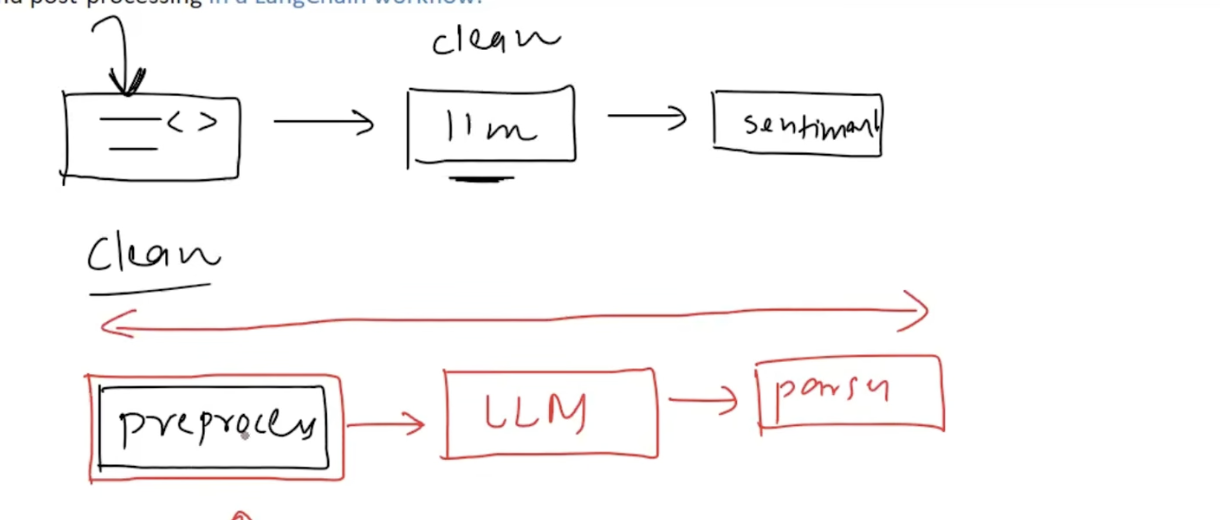

topic -> llm -> joke + no of words in joke (I do not want to ask no of words from LLM)

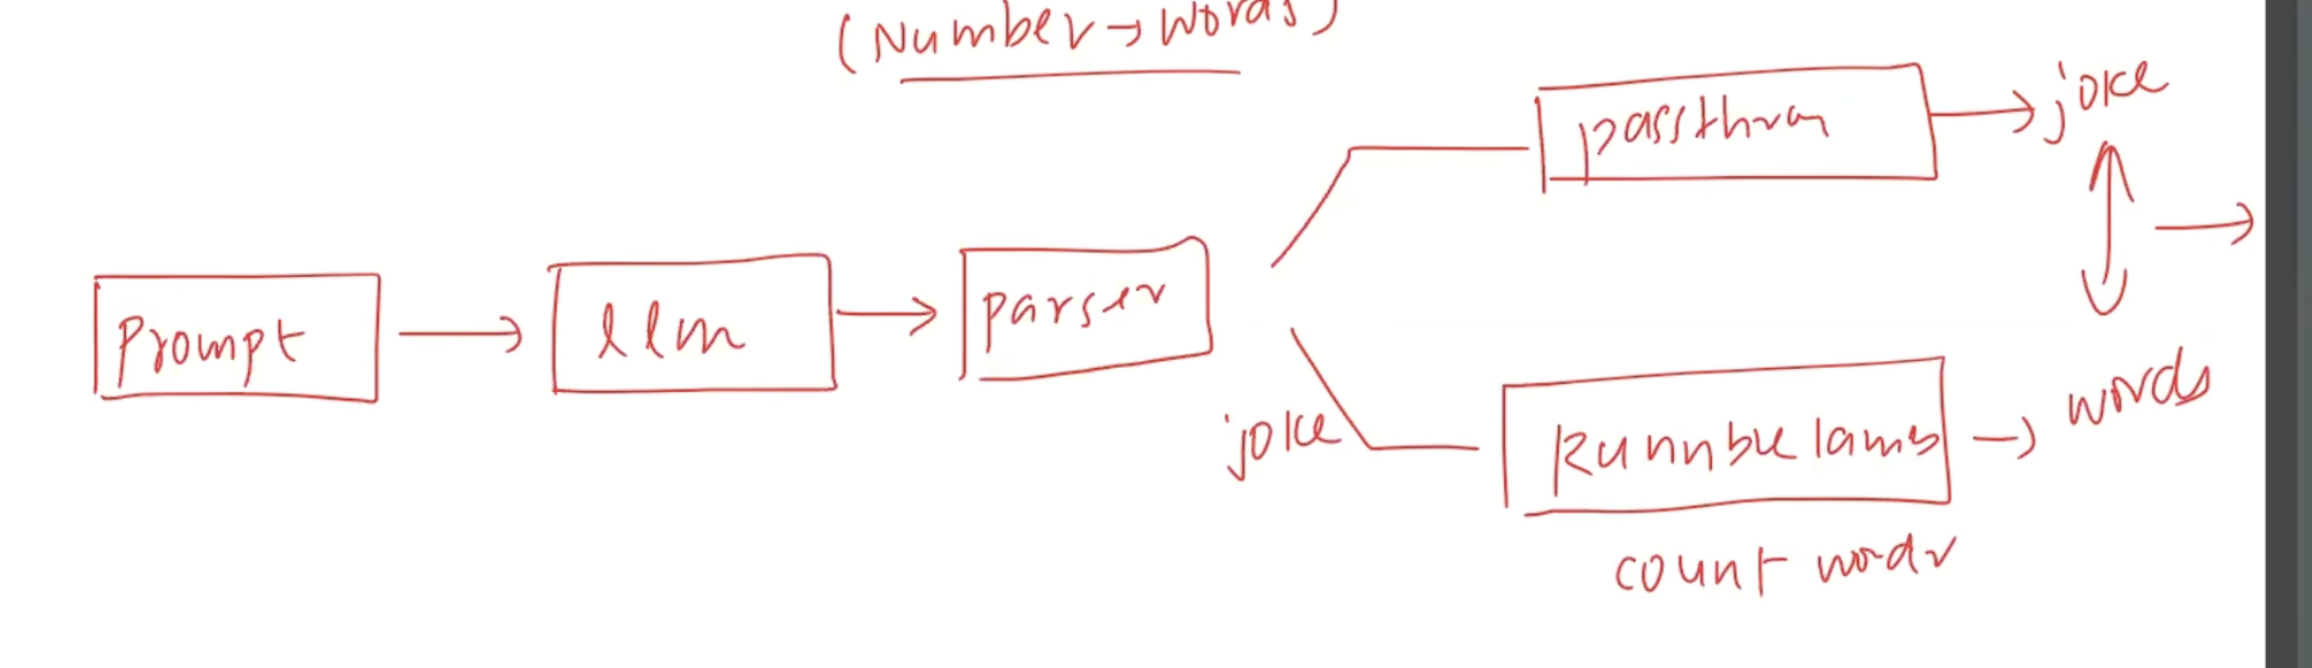

In [17]:
## How runnable lambda works

from langchain_classic.schema.runnable import RunnableLambda

def word_counter(text):
    return len(text.split(" "))

runnable_wordcounter=RunnableLambda(word_counter)

## I convert this function to a runnable

str='Hello How are you my friend'

In [18]:
runnable_wordcounter.invoke(str)

6

In [19]:
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_classic.schema.runnable import RunnableParallel,RunnableSequence,RunnablePassthrough,RunnableLambda

load_dotenv()

True

In [21]:
def word_counter(text):
    return len(text.split())


prompt=PromptTemplate(
    template="Write a joke about {topic}",
    input_variables=['topic']
)

model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

parser=StrOutputParser()


joke_gen_chain=RunnableSequence(prompt,model,parser)

parallel_chain=RunnableParallel({
    'joke':RunnablePassthrough(),
    'word_count':RunnableLambda(lambda x: len(x.split()))
}
)

final_chain=RunnableSequence(joke_gen_chain,parallel_chain)
result=final_chain.invoke({'topic':'relationship ex'})
print(result)

{'joke': 'My ex texted me out of the blue and said, *"I’ve really changed."*\n\nI replied, *"That’s great! Keep the receipt."*', 'word_count': 20}


In [ ]:
final_result="""{} \n word count - {}""".format(result['joke'],result['word_count'])
print(final_result)

My ex texted me out of the blue and said, *"I’ve really changed."*

I replied, *"That’s great! Keep the receipt."* 
 word count - 20


## RunnableBranch

- Used for making conditional chains (langchain ka if-else)

- Control flow component in langchain that allows you to conditionally route input data to different chains or runnables based on custom logic 

- It functions like if/elif/else block for chains where you define a set of condition functions, each associated with a runnable (eg. LLM call, prompt chain, or tool). The first matching condition is executed. If not condition matches, a default runnable is used(if provided).

email from customer ---> LLM 

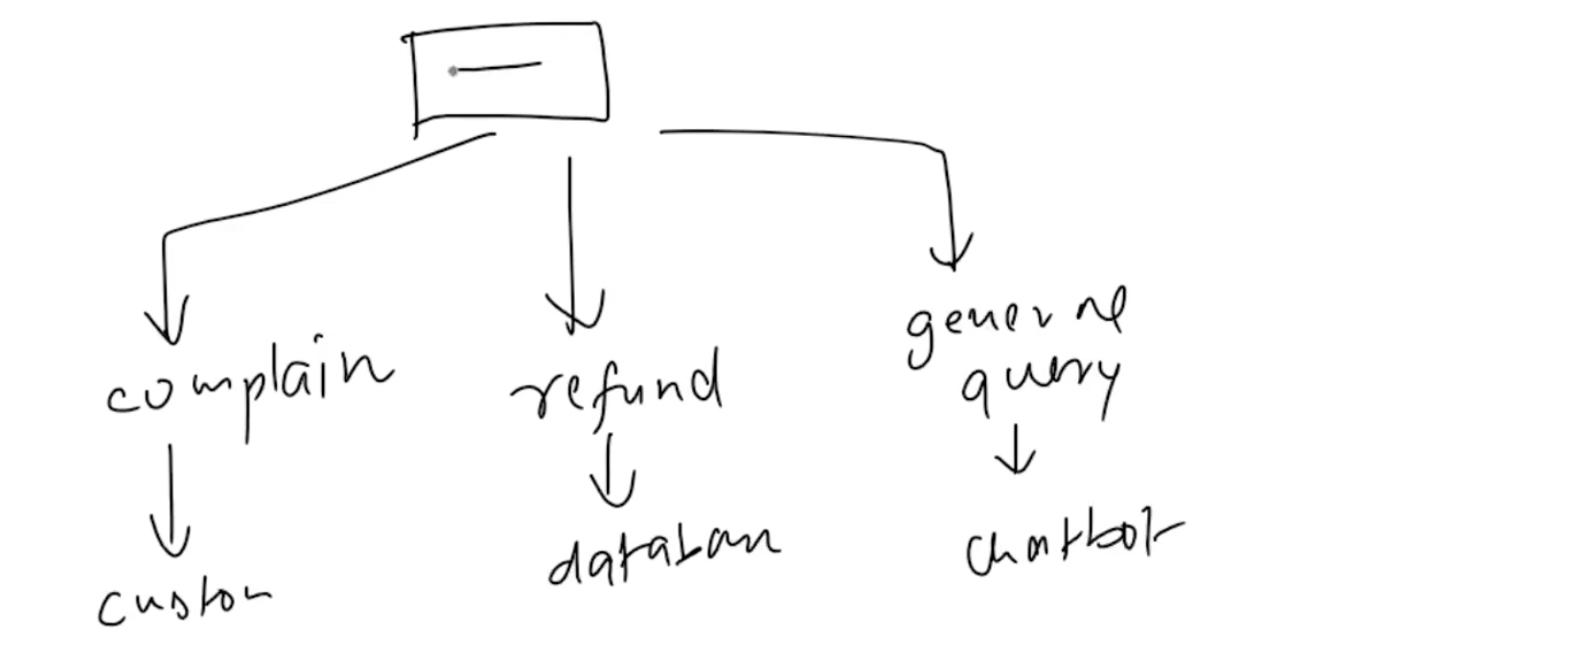

Based on content of email, we want to execute different flow/action

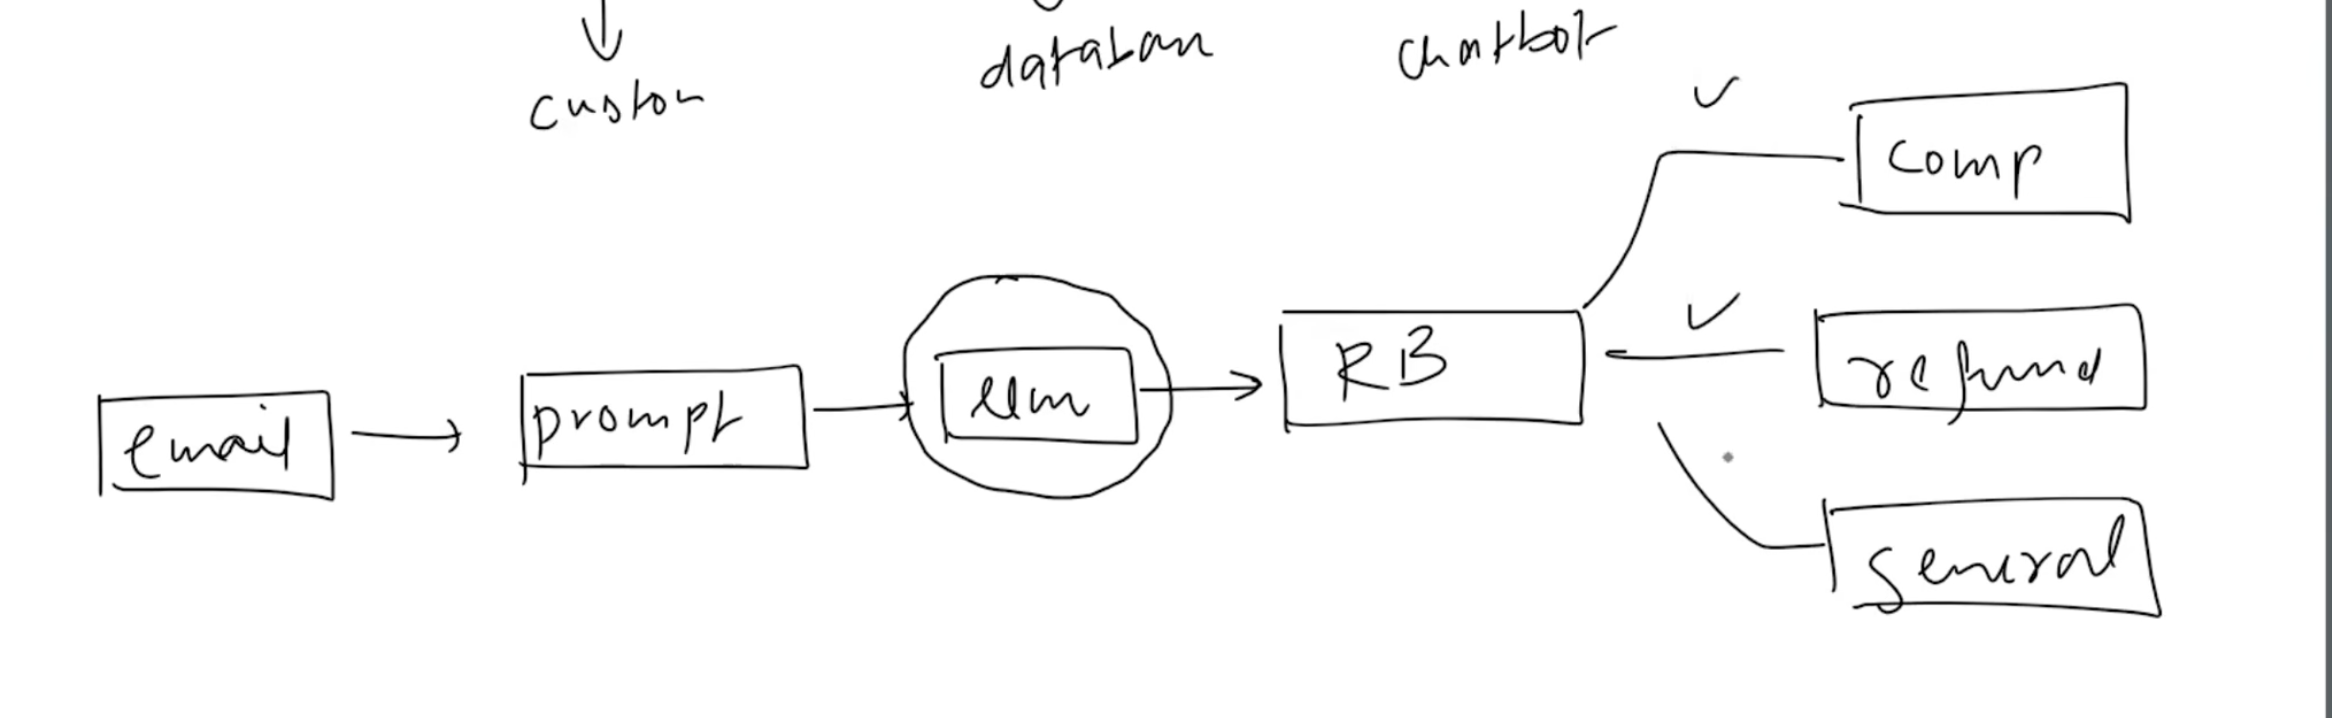



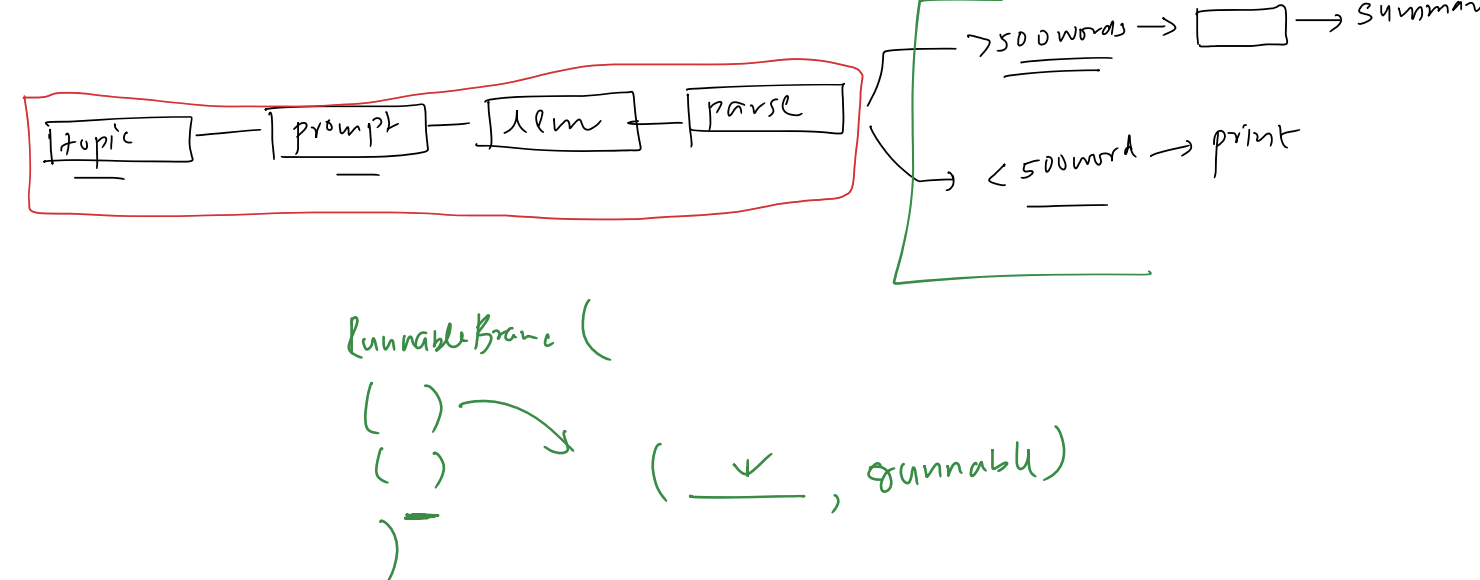

In [23]:
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_classic.schema.runnable import RunnableParallel,RunnableSequence,RunnablePassthrough,RunnableLambda,RunnableBranch

load_dotenv()

True

In [24]:
prompt1=PromptTemplate(
    template="Write a detailed report about {topic}",
    input_variables=['topic']
)
prompt2=PromptTemplate(
    template='Summarize the following text \n {text}',
    input_variables=['text']
)

model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

parser=StrOutputParser()


report_gen_chain=RunnableSequence(prompt1,model,parser)

## you send tuples in runnable branch 

## syntax:
# RunnableBranch(
#       (condition,runnable) this one is for if condition,
#       () this one is for elif condition,
#       ()->default this one is if both conditions do not follow)
branch_chain=RunnableBranch(
        (lambda x: len(x.split()) > 500, RunnableSequence(prompt2,model,parser)),
        RunnablePassthrough()
)

final_chain=RunnableSequence(report_gen_chain,branch_chain)
result=final_chain.invoke({'topic':'Russia vs Ukraine'})
print(result)

Here is a concise summary of the analytical report on the Russo-Ukrainian War:

---

### **Executive Overview**
The Russo-Ukrainian War is Europe’s largest military conflict since World War II. Driven by post-Soviet geopolitical tension, NATO expansion concerns, and Ukraine's shift toward the West, the conflict began with Russia's 2014 annexation of Crimea and backing of Donbas separatists, escalating into a full-scale invasion on February 24, 2022.

---

### **Key Military Phases (2022–Present)**
1. **Battle for Kyiv (Feb–Apr 2022):** Ukraine repelled Russia’s initial attempt at a quick *blitzkrieg* and regime change, forcing Russian forces to withdraw from northern Ukraine.
2. **Donbas Attrition & Coastal Battles (May–Aug 2022):** Russia shifted to heavy artillery warfare in the east, capturing Mariupol after severe destruction.
3. **Ukrainian Counteroffensives (Late 2022):** Ukraine liberated significant territory in the Kharkiv region and recaptured Kherson city using Western-suppl

In [26]:
prompt1=PromptTemplate(
    template="Write a detailed report about {topic}",
    input_variables=['topic']
)
prompt2=PromptTemplate(
    template='Summarize the following text \n {text}',
    input_variables=['text']
)

model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

parser=StrOutputParser()


report_gen_chain=RunnableSequence(prompt1,model,parser)

## you send tuples in runnable branch 

## syntax:
# RunnableBranch(
#       (condition,runnable) this one is for if condition,
#       () this one is for elif condition,
#       ()->default this one is if both conditions do not follow)
branch_chain=RunnableBranch(
        (lambda x: len(x.split()) > 100000, RunnableSequence(prompt2,model,parser)),
        RunnablePassthrough()
)

final_chain=RunnableSequence(report_gen_chain,branch_chain)
result=final_chain.invoke({'topic':'Russia vs Ukraine'})
print(result)

# Comprehensive Report: The Russia-Ukraine Conflict

## Executive Summary

The Russia-Ukraine war represents the largest conventional military conflict in Europe since World War II. Rooted in complex historical, political, and strategic dynamics, the conflict escalated significantly on February 24, 2022, when the Russian Federation launched a full-scale invasion of Ukraine. 

What was initially envisioned by Moscow as a short campaign to overthrow the Ukrainian government transformed into a prolonged, high-intensity war of attrition. The war has reshaped global security architecture, reinvigorated NATO, disrupted global energy and food markets, and resulted in vast humanitarian, economic, and geopolitical consequences.

---

## 1. Historical Background and Root Causes

### A. The Post-Soviet Legacy (1991–2013)
* **Collapse of the USSR:** Following the dissolution of the Soviet Union in 1991, Ukraine gained independence. It possessed the world’s third-largest nuclear arsenal, which it v

## LCEL (Langchain Expression Language)

Runnable Sequence is used everywhere 

RunnableSequence(r1,r2,r3,r4...) is replaced by r1 | r2 | r3 | r4...

They thought second is way better 

the pipe operators are used to define the chain